In [68]:
from tqdm import tqdm
import os

filename = "data/tsp/tsp10-200_concorde.txt"


# Get the total number of lines in the file without iteration
with open(filename, "r") as file:
    total_lines = sum(1 for _ in file)

print(f"Total lines in the file: {total_lines}")


Total lines in the file: 25600


In [69]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __repr__(self):
        return f"({self.x}, {self.y})"
    
    def distance(self, other):
        return ((self.x - other.x) ** 2 + (self.y - other.y) ** 2) ** 0.5

In [70]:
import pandas as pd

num_nodes_col = []
tour_length_col = []

offset = 1280 * 10

# for line in open(filename, "r").readlines()[offset:(offset + 1280)]:
for line in open(filename, "r").readlines():
    line = line.split(" ")
    num_nodes = int(line.index('output') // 2)
    cities_points = [Point(float(line[idx]), float(line[idx + 1])) for idx in range(0, 2 * num_nodes, 2)]
    tour_nodes = [int(node) - 1 for node in line[line.index('output') + 1:-1]]

    tour_length = sum(
        cities_points[tour_nodes[i]].distance(cities_points[tour_nodes[i + 1]])
        for i in range(len(tour_nodes) - 1)
    )
    
    num_nodes_col.append(num_nodes)
    tour_length_col.append(tour_length)


base_df = pd.DataFrame({
    "num_nodes": num_nodes_col,
    "tour_length": tour_length_col,
})
base_df

,num_nodes,tour_length
0,10,2.761457
1,10,2.858019
2,10,3.288704
3,10,2.780503
4,10,2.688265
...,...,...
25595,200,10.687935
25596,200,10.624868
25597,200,11.219512
25598,200,11.124529


In [71]:
# # df.apply(lambda row: df[df.tour_length <= row['tour_length']].count(), axis=1)

total_samples_with_num_nodes = []
lower_equal_tour_lengths_counts = []

grouped_counts = base_df.groupby("num_nodes").count()

for index, row in base_df.iterrows():
    # Count the number of rows with tour_length less than or equal to the current row's tour_length
    upper_limit = row.iloc[1]
    num_nodes = row.iloc[0]

    total_num_nodes = grouped_counts.loc[num_nodes, 'tour_length']
    count = base_df[(base_df.num_nodes == num_nodes) & (base_df.tour_length <= upper_limit)].count().iloc[0]

    total_samples_with_num_nodes.append(total_num_nodes)
    lower_equal_tour_lengths_counts.append(count)

# lower_equal_tour_lengths_counts

df_with_counts = pd.concat([
    base_df, 
    pd.Series(lower_equal_tour_lengths_counts, name='lower_equal_tour_lengths_counts'),
    pd.Series(total_samples_with_num_nodes, name='total_samples_with_num_nodes')
    ],
    axis=1
)

df_with_counts

,num_nodes,tour_length,lower_equal_tour_lengths_counts,total_samples_with_num_nodes
0,10,2.761457,463,1280
1,10,2.858019,601,1280
2,10,3.288704,1140,1280
3,10,2.780503,486,1280
4,10,2.688265,387,1280
...,...,...,...,...
25595,200,10.687935,569,1280
25596,200,10.624868,416,1280
25597,200,11.219512,1275,1280
25598,200,11.124529,1246,1280


In [72]:
df_with_probs = pd.concat([
    df_with_counts,
    pd.Series(
        [count / total for count, total in zip(lower_equal_tour_lengths_counts, total_samples_with_num_nodes)],
        name='probability'
    ),
], axis=1)

df_with_probs

,num_nodes,tour_length,lower_equal_tour_lengths_counts,total_samples_with_num_nodes,probability
0,10,2.761457,463,1280,0.361719
1,10,2.858019,601,1280,0.469531
2,10,3.288704,1140,1280,0.890625
3,10,2.780503,486,1280,0.379688
4,10,2.688265,387,1280,0.302344
...,...,...,...,...,...
25595,200,10.687935,569,1280,0.444531
25596,200,10.624868,416,1280,0.325000
25597,200,11.219512,1275,1280,0.996094
25598,200,11.124529,1246,1280,0.973437


In [73]:
import math


square_size = 1
control_parameter = df_with_probs.apply(
    lambda row: row['tour_length'] / math.sqrt(row["num_nodes"] * square_size),
    axis=1
)

df_with_control_parameter = pd.concat([
    df_with_probs,
    pd.Series(control_parameter, name='control_parameter'),
], axis=1)

df_with_control_parameter

,num_nodes,tour_length,lower_equal_tour_lengths_counts,total_samples_with_num_nodes,probability,control_parameter
0,10,2.761457,463,1280,0.361719,0.873249
1,10,2.858019,601,1280,0.469531,0.903785
2,10,3.288704,1140,1280,0.890625,1.039979
3,10,2.780503,486,1280,0.379688,0.879272
4,10,2.688265,387,1280,0.302344,0.850104
...,...,...,...,...,...,...
25595,200,10.687935,569,1280,0.444531,0.755751
25596,200,10.624868,416,1280,0.325000,0.751292
25597,200,11.219512,1275,1280,0.996094,0.793339
25598,200,11.124529,1246,1280,0.973437,0.786623


C:\Users\omers\AppData\Local\Temp\ipykernel_31408\1448398952.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Probability Range', order=labels, palette='viridis')


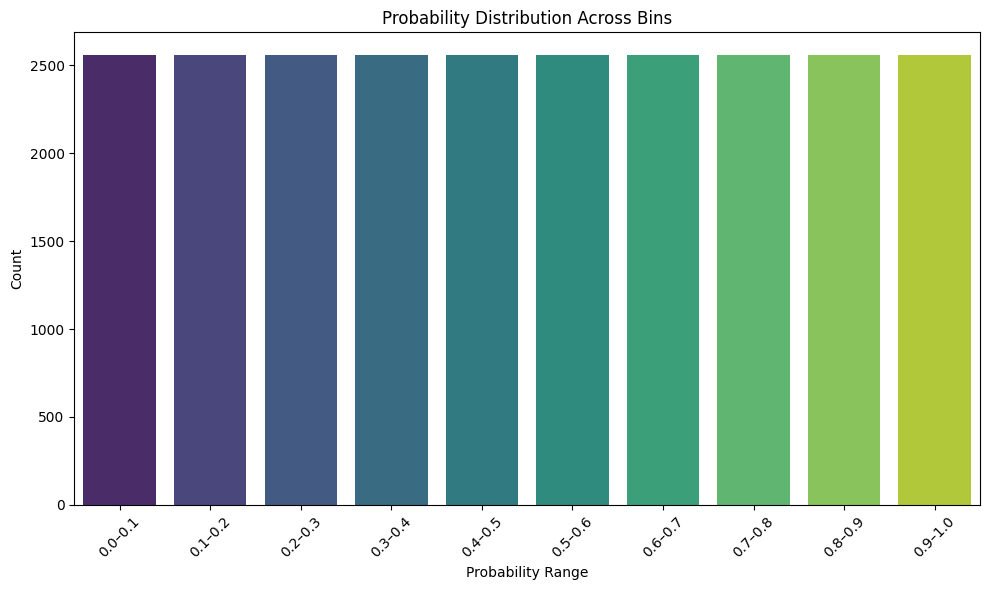

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

probabilities  = df_with_probs['probability'].values
# probabilities = np.random.rand(1280)  # Random probabilities between 0 and 1


# Create bins and labels
bins = np.arange(0, 1.1, 0.1)  # [0.0, 0.1, ..., 1.0]
labels = [f'{round(bins[i], 1)}–{round(bins[i+1], 1)}' for i in range(len(bins)-1)]

# Bin the data
binned_probabilities = pd.cut(probabilities, bins=bins, labels=labels, include_lowest=True)

# Create a DataFrame for plotting
df = pd.DataFrame({'Probability Range': binned_probabilities})

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Probability Range', order=labels, palette='viridis')
plt.title('Probability Distribution Across Bins')
plt.xlabel('Probability Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# df.value_counts()

C:\Users\omers\AppData\Local\Temp\ipykernel_31408\2376692215.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Control Parameter Range', order=labels, palette='viridis')


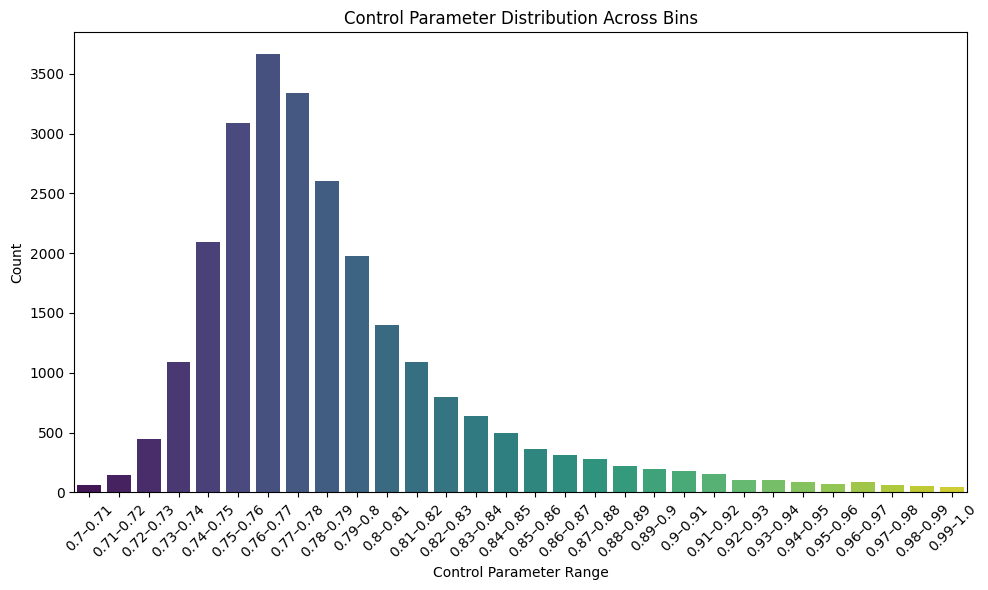

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

control_parameters  = df_with_control_parameter['control_parameter'].values
# probabilities = np.random.rand(1280)  # Random probabilities between 0 and 1


# Create bins and labels
bins = np.arange(0.7, 1.0, 0.01)
labels = [f'{round(bins[i], 2)}–{round(bins[i+1], 2)}' for i in range(len(bins)-1)]

# Bin the data
binned_control_parameters = pd.cut(control_parameters, bins=bins, labels=labels, include_lowest=True)

# Create a DataFrame for plotting
df = pd.DataFrame({'Control Parameter Range': binned_control_parameters})

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Control Parameter Range', order=labels, palette='viridis')
plt.title('Control Parameter Distribution Across Bins')
plt.xlabel('Control Parameter Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# df.value_counts()